# Image Processing Based Smart Supermarket Product Identification System

## Phase 1 — Dataset Analysis

### Dataset
Retail Product Checkout (RPC) Dataset

### Objective
Analyze the RPC dataset to determine:
- Dataset size
- Product categories/classes
- Image distribution
- Annotation distribution
- Bounding-box characteristics
- Suitability for the Smart Supermarket Product Identification System

### Target System
The final system will:
1. Accept supermarket/product-layout images
2. Detect individual products
3. Classify products into selected categories
4. Count products per category
5. Calculate product distribution percentages
6. Generate a statistical summary
7. Display bounding boxes and labels

### Model
YOLO26s

### Training Hardware
NVIDIA A100 GPU

In [1]:
import os
import sys
import json
import zipfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

print("Python version:")
print(sys.version)

Python version:
3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
CUDA version: 12.8


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Verify the RPC folder

In [4]:
from pathlib import Path

RPC_DIR = Path("/content/drive/MyDrive/RPC_Dataset")

print("RPC folder exists:", RPC_DIR.exists())
print("RPC folder:", RPC_DIR)

RPC folder exists: True
RPC folder: /content/drive/MyDrive/RPC_Dataset


In [5]:
for item in RPC_DIR.iterdir():
    print(item.name, " | ", item.stat().st_size / (1024**3), "GB")

instances_test2019.json  |  0.0521258469671011 GB
instances_train2019.json  |  0.013790110126137733 GB
instances_val2019.json  |  0.013077082112431526 GB
val2019.zip  |  1.1709339655935764 GB
train2019.zip  |  2.51434326171875 GB
test2019.zip  |  4.686713173054159 GB


In [6]:
import json

TRAIN_ANN = RPC_DIR / "instances_train2019.json"
VAL_ANN = RPC_DIR / "instances_val2019.json"
TEST_ANN = RPC_DIR / "instances_test2019.json"

print("Train annotation exists:", TRAIN_ANN.exists())
print("Validation annotation exists:", VAL_ANN.exists())
print("Test annotation exists:", TEST_ANN.exists())

Train annotation exists: True
Validation annotation exists: True
Test annotation exists: True


## Load the training annotation

In [7]:
with open(TRAIN_ANN, "r") as f:
    train_data = json.load(f)

print(train_data.keys())

dict_keys(['info', 'licenses', 'categories', '__raw_Chinese_name_df', 'images', 'annotations'])


In [8]:
print("========== TRAINING DATASET ==========")

print("Number of images:", len(train_data["images"]))
print("Number of annotations:", len(train_data["annotations"]))
print("Number of categories:", len(train_data["categories"]))

========== TRAINING DATASET ==========
Number of images: 53739
Number of annotations: 53739
Number of categories: 200


In [9]:
print("\n========== FIRST CATEGORY ==========")
print(train_data["categories"][0])


========== FIRST CATEGORY ==========
{'supercategory': 'puffed_food', 'id': 1, 'name': '1_puffed_food'}


In [10]:
print("\n========== FIRST IMAGE ==========")
print(train_data["images"][0])


========== FIRST IMAGE ==========
{'file_name': '038900004095_camera0-13.jpg', 'width': 2592, 'height': 1944, 'id': 0}


In [11]:
print("\n========== FIRST ANNOTATION ==========")
print(train_data["annotations"][0])


========== FIRST ANNOTATION ==========
{'area': 111763.29, 'bbox': [1188.4, 1052.45, 390.96, 285.87], 'category_id': 112, 'id': 0, 'image_id': 0, 'iscrowd': 0, 'segmentation': [[]], 'point_xy': [1383.88, 1195.38]}


## Load validation and test annotations

In [13]:
# Load validation and test annotation files

with open(VAL_ANN, "r") as f:
    val_data = json.load(f)

with open(TEST_ANN, "r") as f:
    test_data = json.load(f)

print("Validation and test annotation files loaded successfully.")

Validation and test annotation files loaded successfully.


## COMPLETE DATASET SUMMARY

In [14]:
print("========== COMPLETE DATASET SUMMARY ==========")

print("\nTRAIN")
print("Images:", len(train_data["images"]))
print("Annotations:", len(train_data["annotations"]))
print("Categories:", len(train_data["categories"]))

print("\nVALIDATION")
print("Images:", len(val_data["images"]))
print("Annotations:", len(val_data["annotations"]))
print("Categories:", len(val_data["categories"]))

print("\nTEST")
print("Images:", len(test_data["images"]))
print("Annotations:", len(test_data["annotations"]))
print("Categories:", len(test_data["categories"]))

========== COMPLETE DATASET SUMMARY ==========

TRAIN
Images: 53739
Annotations: 53739
Categories: 200

VALIDATION
Images: 6000
Annotations: 73602
Categories: 200

TEST
Images: 24000
Annotations: 294333
Categories: 200


## category analysis

In [15]:
categories_df = pd.DataFrame(train_data["categories"])

print("Number of categories:", len(categories_df))

display(categories_df.head(20))

Number of categories: 200


,supercategory,id,name
0,puffed_food,1,1_puffed_food
1,puffed_food,2,2_puffed_food
2,puffed_food,3,3_puffed_food
3,puffed_food,4,4_puffed_food
4,puffed_food,5,5_puffed_food
5,puffed_food,6,6_puffed_food
6,puffed_food,7,7_puffed_food
7,puffed_food,8,8_puffed_food
8,puffed_food,9,9_puffed_food
9,puffed_food,10,10_puffed_food


In [16]:
print("========== SUPERCATEGORY ANALYSIS ==========")

print("Unique supercategories:",
      categories_df["supercategory"].nunique())

print("\nNumber of products/classes per supercategory:")

supercategory_counts = (
    categories_df["supercategory"]
    .value_counts()
    .reset_index()
)

supercategory_counts.columns = [
    "supercategory",
    "number_of_classes"
]

display(supercategory_counts)

========== SUPERCATEGORY ANALYSIS ==========
Unique supercategories: 17

Number of products/classes per supercategory:


,supercategory,number_of_classes
0,tissue,20
1,dessert,17
2,drink,15
3,canned_food,14
4,puffed_food,12
5,chocolate,12
6,seasoner,12
7,instant_noodles,12
8,instant_drink,11
9,milk,11


In [17]:
print("========== CATEGORY MAPPING ==========")

display(
    categories_df[
        ["id", "name", "supercategory"]
    ].sort_values("id")
)

========== CATEGORY MAPPING ==========


,id,name,supercategory
0,1,1_puffed_food,puffed_food
1,2,2_puffed_food,puffed_food
2,3,3_puffed_food,puffed_food
3,4,4_puffed_food,puffed_food
4,5,5_puffed_food,puffed_food
...,...,...,...
195,196,196_stationery,stationery
196,197,197_stationery,stationery
197,198,198_stationery,stationery
198,199,199_stationery,stationery


## analyze all three splits

In [18]:
print("========== COMPLETE DATASET SUMMARY ==========")

for name, data in [
    ("TRAIN", train_data),
    ("VALIDATION", val_data),
    ("TEST", test_data)
]:
    print(f"\n{name}")
    print("Images:", len(data["images"]))
    print("Annotations:", len(data["annotations"]))
    print("Categories:", len(data["categories"]))

========== COMPLETE DATASET SUMMARY ==========

TRAIN
Images: 53739
Annotations: 53739
Categories: 200

VALIDATION
Images: 6000
Annotations: 73602
Categories: 200

TEST
Images: 24000
Annotations: 294333
Categories: 200


## analyze the supercategories in the training data

In [19]:
# Create annotation DataFrame
train_annotations_df = pd.DataFrame(train_data["annotations"])

# Create category DataFrame
categories_df = pd.DataFrame(train_data["categories"])

# Add supercategory information to every annotation
train_annotations_df = train_annotations_df.merge(
    categories_df[["id", "name", "supercategory"]],
    left_on="category_id",
    right_on="id",
    how="left"
)

# Count annotations per supercategory
supercategory_distribution = (
    train_annotations_df["supercategory"]
    .value_counts()
    .reset_index()
)

supercategory_distribution.columns = [
    "supercategory",
    "annotation_count"
]

display(supercategory_distribution)

,supercategory,annotation_count
0,tissue,6719
1,dessert,5278
2,chocolate,4320
3,puffed_food,3840
4,seasoner,3200
5,candy,3040
6,instant_noodles,3039
7,instant_drink,2878
8,dried_food,2875
9,dried_fruit,2873


## calculate percentage

In [20]:
supercategory_distribution["percentage"] = (
    supercategory_distribution["annotation_count"]
    / supercategory_distribution["annotation_count"].sum()
    * 100
)

display(supercategory_distribution)

,supercategory,annotation_count,percentage
0,tissue,6719,12.503024
1,dessert,5278,9.821545
2,chocolate,4320,8.038854
3,puffed_food,3840,7.145648
4,seasoner,3200,5.954707
5,candy,3040,5.656972
6,instant_noodles,3039,5.655111
7,instant_drink,2878,5.355515
8,dried_food,2875,5.349932
9,dried_fruit,2873,5.346210


## check how many training images each category has

In [21]:
train_image_category = (
    train_annotations_df
    .groupby("supercategory")["image_id"]
    .nunique()
    .reset_index(name="unique_images")
    .sort_values("unique_images", ascending=False)
)

display(train_image_category)

,supercategory,unique_images
16,tissue,6719
4,dessert,5278
3,chocolate,4320
13,puffed_food,3840
14,seasoner,3200
1,candy,3040
10,instant_noodles,3039
9,instant_drink,2878
5,dried_food,2875
6,dried_fruit,2873


## investigate the checkout images

In [22]:
# ==========================================
# PRODUCTS PER IMAGE - VALIDATION
# ==========================================

val_annotations_df = pd.DataFrame(val_data["annotations"])

val_products_per_image = (
    val_annotations_df
    .groupby("image_id")
    .size()
)

print("========== VALIDATION PRODUCTS PER IMAGE ==========")
print(val_products_per_image.describe())

========== VALIDATION PRODUCTS PER IMAGE ==========
count    6000.00000
mean       12.26700
std         4.44466
min         4.00000
25%         8.00000
50%        12.00000
75%        16.00000
max        20.00000
dtype: float64


In [23]:
print("\nValidation product-count distribution:")
print(
    val_products_per_image
    .value_counts()
    .sort_index()
)


Validation product-count distribution:
4     102
5     294
6     321
7     407
8     385
9     362
10    411
11    395
12    360
13    412
14    374
15    537
16    377
17    325
18    403
19    322
20    213
Name: count, dtype: int64


## PRODUCTS PER IMAGE - TEST

In [24]:
# ==========================================
# PRODUCTS PER IMAGE - TEST
# ==========================================

test_annotations_df = pd.DataFrame(test_data["annotations"])

test_products_per_image = (
    test_annotations_df
    .groupby("image_id")
    .size()
)

print("========== TEST PRODUCTS PER IMAGE ==========")
print(test_products_per_image.describe())

========== TEST PRODUCTS PER IMAGE ==========
count    24000.000000
mean        12.263875
std          4.468323
min          3.000000
25%          9.000000
50%         12.000000
75%         16.000000
max         20.000000
dtype: float64


In [25]:
print("\nTest product-count distribution:")
print(
    test_products_per_image
    .value_counts()
    .sort_index()
)


Test product-count distribution:
3      104
4      417
5      907
6     1400
7     1666
8     1467
9     1488
10    1934
11    1394
12    1555
13    1531
14    1553
15    1904
16    1347
17    1508
18    1644
19    1311
20     870
Name: count, dtype: int64


## Calculate the exact average

In [26]:
print("Average products per validation image:",
      val_products_per_image.mean())

print("Average products per test image:",
      test_products_per_image.mean())

print("Maximum products in validation image:",
      val_products_per_image.max())

print("Maximum products in test image:",
      test_products_per_image.max())

Average products per validation image: 12.267
Average products per test image: 12.263875
Maximum products in validation image: 20
Maximum products in test image: 20


## know the actual filenames in the JSON

In [27]:
print("========== VALIDATION IMAGE EXAMPLES ==========")

for img in val_data["images"][:10]:
    print(img)

========== VALIDATION IMAGE EXAMPLES ==========
{'file_name': '20180827-16-07-06-756.jpg', 'width': 1850, 'height': 1850, 'id': 220, 'level': 'easy'}
{'file_name': '20180827-16-07-10-756.jpg', 'width': 1840, 'height': 1840, 'id': 221, 'level': 'easy'}
{'file_name': '20180827-16-24-37-306.jpg', 'width': 1826, 'height': 1826, 'id': 222, 'level': 'easy'}
{'file_name': '20180827-16-24-44-306.jpg', 'width': 1829, 'height': 1829, 'id': 223, 'level': 'easy'}
{'file_name': '20180827-16-24-53-306.jpg', 'width': 1826, 'height': 1826, 'id': 224, 'level': 'easy'}
{'file_name': '20180828-09-26-08-366.jpg', 'width': 1817, 'height': 1817, 'id': 228, 'level': 'easy'}
{'file_name': '20180828-09-26-22-366.jpg', 'width': 1823, 'height': 1823, 'id': 229, 'level': 'easy'}
{'file_name': '20180828-09-26-33-366.jpg', 'width': 1805, 'height': 1805, 'id': 230, 'level': 'easy'}
{'file_name': '20180828-09-33-25-1021.jpg', 'width': 1789, 'height': 1789, 'id': 234, 'level': 'easy'}
{'file_name': '20180828-09-33-30-

In [28]:
print("\n========== TEST IMAGE EXAMPLES ==========")

for img in test_data["images"][:10]:
    print(img)


========== TEST IMAGE EXAMPLES ==========
{'file_name': '20180824-15-44-39-474.jpg', 'width': 1831, 'height': 1831, 'id': 3, 'level': 'easy'}
{'file_name': '20180824-15-44-47-474.jpg', 'width': 1834, 'height': 1834, 'id': 4, 'level': 'easy'}
{'file_name': '20180824-15-44-56-474.jpg', 'width': 1839, 'height': 1839, 'id': 5, 'level': 'easy'}
{'file_name': '20180824-15-50-57-480.jpg', 'width': 1827, 'height': 1827, 'id': 6, 'level': 'easy'}
{'file_name': '20180824-15-51-04-480.jpg', 'width': 1831, 'height': 1831, 'id': 7, 'level': 'easy'}
{'file_name': '20180824-16-12-49-495.jpg', 'width': 1850, 'height': 1850, 'id': 8, 'level': 'easy'}
{'file_name': '20180824-16-12-54-495.jpg', 'width': 1863, 'height': 1863, 'id': 9, 'level': 'easy'}
{'file_name': '20180824-16-12-59-495.jpg', 'width': 1870, 'height': 1870, 'id': 10, 'level': 'easy'}
{'file_name': '20180824-16-58-18-80.jpg', 'width': 1830, 'height': 1830, 'id': 11, 'level': 'easy'}
{'file_name': '20180824-16-58-25-80.jpg', 'width': 1852,

## CHECKOUT DIFFICULTY DISTRIBUTION

In [29]:
# ==========================================
# CHECKOUT DIFFICULTY DISTRIBUTION
# ==========================================

val_images_df = pd.DataFrame(val_data["images"])
test_images_df = pd.DataFrame(test_data["images"])

print("========== VALIDATION LEVEL DISTRIBUTION ==========")
print(val_images_df["level"].value_counts())

print("\n========== TEST LEVEL DISTRIBUTION ==========")
print(test_images_df["level"].value_counts())

========== VALIDATION LEVEL DISTRIBUTION ==========
level
easy      2000
medium    2000
hard      2000
Name: count, dtype: int64

========== TEST LEVEL DISTRIBUTION ==========
level
easy      8000
medium    8000
hard      8000
Name: count, dtype: int64


In [30]:
print("========== VALIDATION LEVEL PERCENTAGE ==========")

print(
    val_images_df["level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n========== TEST LEVEL PERCENTAGE ==========")

print(
    test_images_df["level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

========== VALIDATION LEVEL PERCENTAGE ==========
level
easy      33.33
medium    33.33
hard      33.33
Name: proportion, dtype: float64

========== TEST LEVEL PERCENTAGE ==========
level
easy      33.33
medium    33.33
hard      33.33
Name: proportion, dtype: float64


In [31]:
RPC_DIR = Path("/content/drive/MyDrive/RPC_Dataset")

In [32]:
import zipfile

TRAIN_ZIP = RPC_DIR / "train2019.zip"
VAL_ZIP = RPC_DIR / "val2019.zip"
TEST_ZIP = RPC_DIR / "test2019.zip"

print("Train ZIP:", TRAIN_ZIP.exists(), TRAIN_ZIP)
print("Val ZIP:", VAL_ZIP.exists(), VAL_ZIP)
print("Test ZIP:", TEST_ZIP.exists(), TEST_ZIP)

Train ZIP: True /content/drive/MyDrive/RPC_Dataset/train2019.zip
Val ZIP: True /content/drive/MyDrive/RPC_Dataset/val2019.zip
Test ZIP: True /content/drive/MyDrive/RPC_Dataset/test2019.zip


In [33]:
with zipfile.ZipFile(VAL_ZIP, "r") as z:
    names = z.namelist()

print("Number of files in validation ZIP:", len(names))

print("\nFirst 20 entries:")
for name in names[:20]:
    print(name)

Number of files in validation ZIP: 6001

First 20 entries:
val2019/
val2019/20180824-13-43-21-401.jpg
val2019/20180824-13-43-33-401.jpg
val2019/20180824-13-50-07-6.jpg
val2019/20180824-13-50-21-6.jpg
val2019/20180824-13-50-43-6.jpg
val2019/20180824-13-54-50-406.jpg
val2019/20180824-13-55-03-406.jpg
val2019/20180824-13-55-12-406.jpg
val2019/20180824-14-02-57-411.jpg
val2019/20180824-14-03-11-411.jpg
val2019/20180824-14-03-18-411.jpg
val2019/20180824-14-09-07-416.jpg
val2019/20180824-14-09-16-416.jpg
val2019/20180824-14-09-24-416.jpg
val2019/20180824-14-11-02-16.jpg
val2019/20180824-14-11-13-16.jpg
val2019/20180824-14-11-23-16.jpg
val2019/20180824-14-23-42-421.jpg
val2019/20180824-14-23-51-421.jpg


In [34]:
with zipfile.ZipFile(TEST_ZIP, "r") as z:
    test_zip_names = z.namelist()

print("Number of files in test ZIP:", len(test_zip_names))

print("\nFirst 20 entries:")
for name in test_zip_names[:20]:
    print(name)

Number of files in test ZIP: 24001

First 20 entries:
test2019/
test2019/20180824-13-35-55-2.jpg
test2019/20180824-13-36-25-2.jpg
test2019/20180824-13-36-40-2.jpg
test2019/20180824-13-42-49-3.jpg
test2019/20180824-13-43-04-3.jpg
test2019/20180824-13-43-16-3.jpg
test2019/20180824-13-45-00-4.jpg
test2019/20180824-13-45-13-4.jpg
test2019/20180824-13-45-29-4.jpg
test2019/20180824-13-47-42-5.jpg
test2019/20180824-13-47-56-5.jpg
test2019/20180824-13-48-38-5.jpg
test2019/20180824-13-48-58-402.jpg
test2019/20180824-13-49-06-402.jpg
test2019/20180824-13-50-31-403.jpg
test2019/20180824-13-50-42-403.jpg
test2019/20180824-13-51-40-7.jpg
test2019/20180824-13-51-59-7.jpg
test2019/20180824-13-52-07-404.jpg


## TRAINING IMAGES PER SKU

In [35]:
# ==========================================
# TRAINING IMAGES PER SKU
# ==========================================

train_categories_df = pd.DataFrame(train_data["categories"])

train_annotations_df = pd.DataFrame(train_data["annotations"])

train_annotations_df = train_annotations_df.merge(
    train_categories_df[
        ["id", "name", "supercategory"]
    ],
    left_on="category_id",
    right_on="id",
    how="left"
)

sku_image_counts = (
    train_annotations_df
    .groupby(
        ["supercategory", "category_id", "name"]
    )["image_id"]
    .nunique()
    .reset_index(name="image_count")
)

sku_image_counts = sku_image_counts.sort_values(
    ["supercategory", "image_count"],
    ascending=[True, True]
)

display(sku_image_counts)

,supercategory,category_id,name,image_count
8,alcohol,94,94_alcohol,159
0,alcohol,79,79_alcohol,160
1,alcohol,80,80_alcohol,160
2,alcohol,88,88_alcohol,160
3,alcohol,89,89_alcohol,160
...,...,...,...,...
195,tissue,189,189_tissue,320
197,tissue,191,191_tissue,320
198,tissue,192,192_tissue,320
199,tissue,193,193_tissue,320


## check the minimum SKU count

In [36]:
print("Minimum images available for any SKU:",
      sku_image_counts["image_count"].min())

print("\nMaximum images available for any SKU:",
      sku_image_counts["image_count"].max())

print("\nMean images per SKU:",
      sku_image_counts["image_count"].mean())

Minimum images available for any SKU: 158

Maximum images available for any SKU: 640

Mean images per SKU: 268.695


In [37]:
print("\nSKUs with fewer than 20 images:")

display(
    sku_image_counts[
        sku_image_counts["image_count"] < 20
    ]
)


SKUs with fewer than 20 images:


,supercategory,category_id,name,image_count


## Image Distribution Analysis

In [38]:
# ==========================================
# 9. IMAGE DISTRIBUTION ANALYSIS
# ==========================================

train_images_df = pd.DataFrame(train_data["images"])
val_images_df = pd.DataFrame(val_data["images"])
test_images_df = pd.DataFrame(test_data["images"])

print("========== TRAIN IMAGE DIMENSIONS ==========")
print(train_images_df[["width", "height"]].describe())

print("\n========== VALIDATION IMAGE DIMENSIONS ==========")
print(val_images_df[["width", "height"]].describe())

print("\n========== TEST IMAGE DIMENSIONS ==========")
print(test_images_df[["width", "height"]].describe())

========== TRAIN IMAGE DIMENSIONS ==========
         width   height
count  53739.0  53739.0
mean    2592.0   1944.0
std        0.0      0.0
min     2592.0   1944.0
25%     2592.0   1944.0
50%     2592.0   1944.0
75%     2592.0   1944.0
max     2592.0   1944.0

========== VALIDATION IMAGE DIMENSIONS ==========
             width       height
count  6000.000000  6000.000000
mean   1830.739333  1830.739333
std      20.213176    20.213176
min    1751.000000  1751.000000
25%    1817.000000  1817.000000
50%    1833.000000  1833.000000
75%    1846.000000  1846.000000
max    1887.000000  1887.000000

========== TEST IMAGE DIMENSIONS ==========
              width        height
count  24000.000000  24000.000000
mean    1830.866583   1830.866542
std       20.237546     20.237487
min     1751.000000   1751.000000
25%     1817.000000   1817.000000
50%     1833.000000   1833.000000
75%     1846.000000   1846.000000
max     1906.000000   1906.000000


In [39]:
print("\n========== MOST COMMON TRAIN DIMENSIONS ==========")

display(
    train_images_df[
        ["width", "height"]
    ].value_counts().head(10)
)


========== MOST COMMON TRAIN DIMENSIONS ==========


,,count
width,height,
2592,1944,53739


In [40]:
print("\n========== MOST COMMON VALIDATION DIMENSIONS ==========")

display(
    val_images_df[
        ["width", "height"]
    ].value_counts().head(10)
)

print("\n========== MOST COMMON TEST DIMENSIONS ==========")

display(
    test_images_df[
        ["width", "height"]
    ].value_counts().head(10)
)


========== MOST COMMON VALIDATION DIMENSIONS ==========


,,count
width,height,
1838,1838,230
1843,1843,174
1836,1836,172
1850,1850,168
1830,1830,160
1815,1815,153
1825,1825,149
1840,1840,144
1841,1841,139



========== MOST COMMON TEST DIMENSIONS ==========


,,count
width,height,
1838,1838,922
1843,1843,747
1850,1850,707
1830,1830,706
1836,1836,680
1815,1815,610
1841,1841,559
1832,1832,557
1825,1825,548


## Bounding Box Analysis

In [41]:
# ==========================================
# 10. BOUNDING BOX ANALYSIS
# ==========================================

train_annotations_df = pd.DataFrame(train_data["annotations"])
val_annotations_df = pd.DataFrame(val_data["annotations"])
test_annotations_df = pd.DataFrame(test_data["annotations"])

for df in [
    train_annotations_df,
    val_annotations_df,
    test_annotations_df
]:
    df["bbox_width"] = df["bbox"].apply(lambda x: x[2])
    df["bbox_height"] = df["bbox"].apply(lambda x: x[3])
    df["bbox_area"] = (
        df["bbox_width"] * df["bbox_height"]
    )

In [42]:
print("========== TRAIN BOUNDING BOXES ==========")
display(
    train_annotations_df[
        ["bbox_width", "bbox_height", "bbox_area"]
    ].describe()
)

print("========== VALIDATION BOUNDING BOXES ==========")
display(
    val_annotations_df[
        ["bbox_width", "bbox_height", "bbox_area"]
    ].describe()
)

print("========== TEST BOUNDING BOXES ==========")
display(
    test_annotations_df[
        ["bbox_width", "bbox_height", "bbox_area"]
    ].describe()
)

========== TRAIN BOUNDING BOXES ==========


,bbox_width,bbox_height,bbox_area
count,53739.000000,53739.000000,5.373900e+04
mean,632.588568,486.859865,3.269976e+05
std,322.920497,256.473220,2.990389e+05
min,90.870000,53.920000,1.174429e+04
25%,349.390000,289.360000,1.260896e+05
50%,601.140000,452.540000,2.450445e+05
75%,826.000000,625.470000,4.211654e+05
max,2012.120000,1668.910000,2.612831e+06


========== VALIDATION BOUNDING BOXES ==========


,bbox_width,bbox_height,bbox_area
count,73602.000000,73602.000000,7.360200e+04
mean,359.352928,382.132765,1.508134e+05
std,147.536463,150.528411,1.191782e+05
min,19.970000,7.490000,1.495753e+02
25%,245.695000,270.070000,7.135165e+04
50%,337.330000,359.075000,1.151227e+05
75%,445.270000,469.427500,1.935928e+05
max,1068.140000,1091.860000,1.075853e+06


========== TEST BOUNDING BOXES ==========


,bbox_width,bbox_height,bbox_area
count,294333.000000,294333.000000,2.943330e+05
mean,361.269631,382.333341,1.518689e+05
std,148.714630,151.066521,1.207161e+05
min,29.650000,52.360000,3.765208e+03
25%,247.100000,271.020000,7.142732e+04
50%,338.950000,358.960000,1.158536e+05
75%,447.160000,470.500000,1.952284e+05
max,1113.910000,1083.350000,1.120425e+06


## Checkout Image Analysis

In [43]:
# ==========================================
# 11. CHECKOUT IMAGE ANALYSIS
# ==========================================

val_checkout_analysis = val_images_df[
    ["id", "file_name", "level"]
].copy()

val_checkout_analysis["product_count"] = (
    val_checkout_analysis["id"]
    .map(val_products_per_image)
)

test_checkout_analysis = test_images_df[
    ["id", "file_name", "level"]
].copy()

test_checkout_analysis["product_count"] = (
    test_checkout_analysis["id"]
    .map(test_products_per_image)
)

print("========== VALIDATION CHECKOUT ANALYSIS ==========")

display(
    val_checkout_analysis.groupby("level")[
        "product_count"
    ].describe()
)

========== VALIDATION CHECKOUT ANALYSIS ==========


,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,2000.0,7.1405,1.638933,4.0,6.0,7.0,8.0,10.0
hard,2000.0,17.2945,1.620828,15.0,16.0,17.0,19.0,20.0
medium,2000.0,12.3660,1.542476,10.0,11.0,12.0,14.0,15.0


In [44]:
# ==========================================
# 11. CHECKOUT IMAGE ANALYSIS
# ==========================================

val_checkout_analysis = val_images_df[
    ["id", "file_name", "level"]
].copy()

val_checkout_analysis["product_count"] = (
    val_checkout_analysis["id"]
    .map(val_products_per_image)
)

test_checkout_analysis = test_images_df[
    ["id", "file_name", "level"]
].copy()

test_checkout_analysis["product_count"] = (
    test_checkout_analysis["id"]
    .map(test_products_per_image)
)

print("========== VALIDATION CHECKOUT ANALYSIS ==========")

display(
    val_checkout_analysis.groupby("level")[
        "product_count"
    ].describe()
)

========== VALIDATION CHECKOUT ANALYSIS ==========


,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,2000.0,7.1405,1.638933,4.0,6.0,7.0,8.0,10.0
hard,2000.0,17.2945,1.620828,15.0,16.0,17.0,19.0,20.0
medium,2000.0,12.3660,1.542476,10.0,11.0,12.0,14.0,15.0


## Sample Image Visualization

Sample image: 20180827-16-07-06-756.jpg
Image size: (1850, 1850)


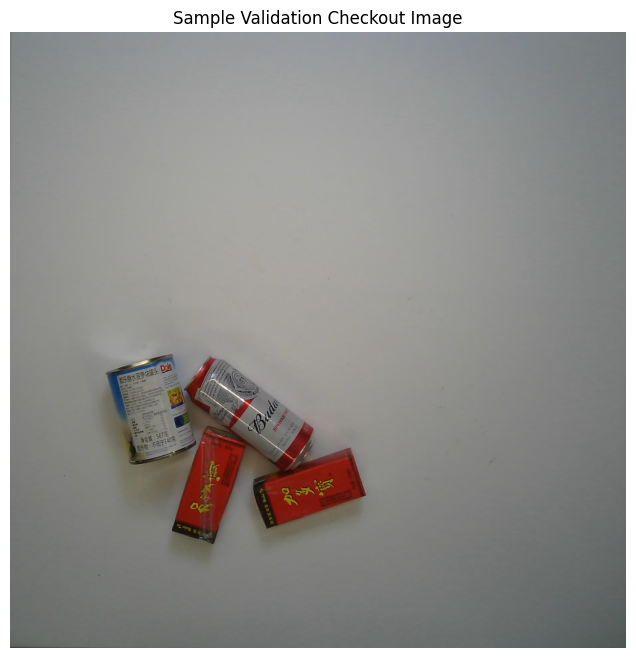

In [45]:
# ==========================================
# 12. SAMPLE IMAGE VISUALIZATION
# ==========================================

import zipfile
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

sample_file = val_data["images"][0]["file_name"]

print("Sample image:", sample_file)

with zipfile.ZipFile(VAL_ZIP, "r") as z:
    image_bytes = z.read("val2019/" + sample_file)

image = Image.open(BytesIO(image_bytes))

print("Image size:", image.size)

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Sample Validation Checkout Image")
plt.show()

## Draw the bounding boxes

Number of products: 4


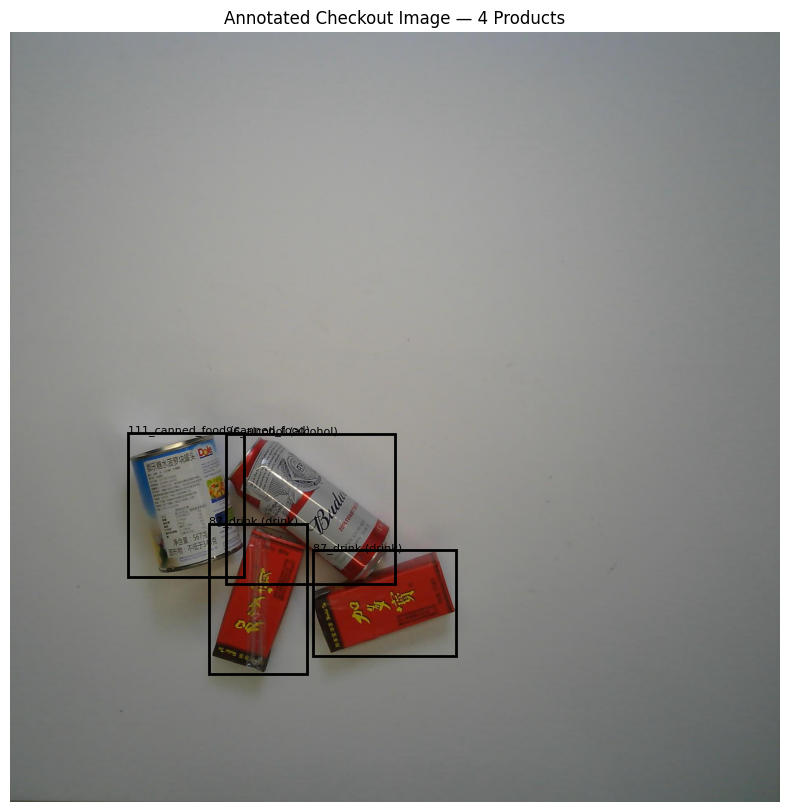

In [46]:
# Get image ID
sample_image_info = val_data["images"][0]
sample_image_id = sample_image_info["id"]

# Get annotations for this image
sample_annotations = [
    ann for ann in val_data["annotations"]
    if ann["image_id"] == sample_image_id
]

# Category lookup
category_lookup = {
    cat["id"]: cat
    for cat in val_data["categories"]
}

print("Number of products:", len(sample_annotations))

plt.figure(figsize=(10, 10))
plt.imshow(image)

ax = plt.gca()

for ann in sample_annotations:

    x, y, w, h = ann["bbox"]

    rect = plt.Rectangle(
        (x, y),
        w,
        h,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rect)

    category = category_lookup[
        ann["category_id"]
    ]

    label = (
        f'{category["name"]} '
        f'({category["supercategory"]})'
    )

    ax.text(
        x,
        y,
        label,
        fontsize=8
    )

plt.axis("off")
plt.title(
    f"Annotated Checkout Image — "
    f"{len(sample_annotations)} Products"
)

plt.show()

## Class Distribution Visualization

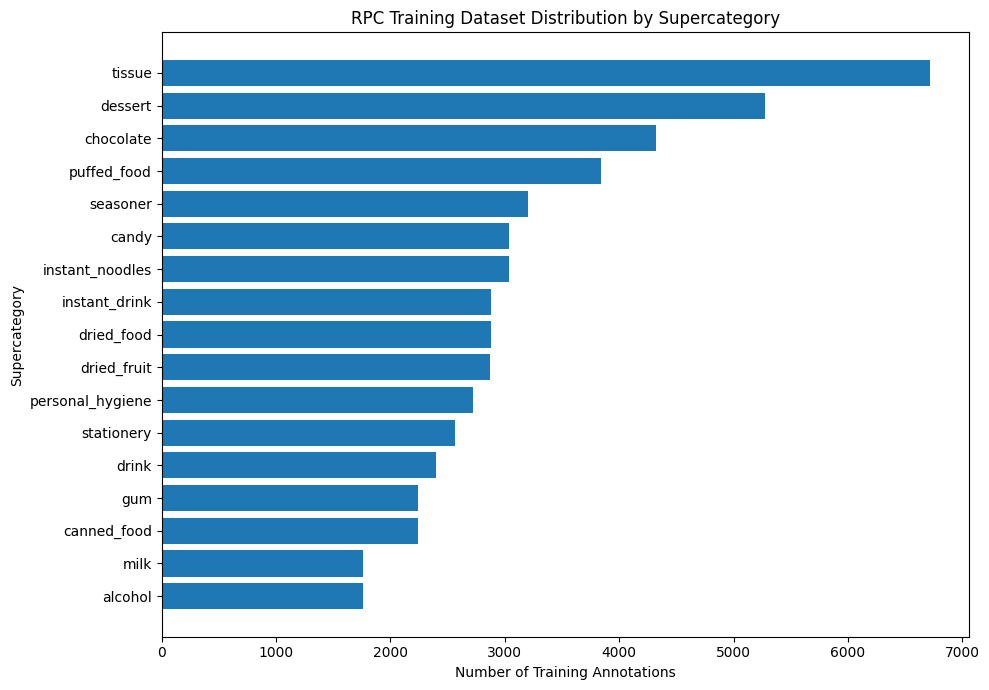

In [47]:
# ==========================================
# 13. CLASS DISTRIBUTION VISUALIZATION
# ==========================================

supercategory_distribution = (
    train_annotations_df
    .merge(
        categories_df[["id", "supercategory"]],
        left_on="category_id",
        right_on="id",
        how="left"
    )
    ["supercategory"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    supercategory_distribution.index,
    supercategory_distribution.values
)

plt.xlabel("Number of Training Annotations")
plt.ylabel("Supercategory")
plt.title("RPC Training Dataset Distribution by Supercategory")

plt.tight_layout()
plt.show()

## Initial Dataset Selection Analysis

In [48]:
sku_image_counts = (
    train_annotations_df
    .merge(
        categories_df[
            ["id", "name", "supercategory"]
        ],
        left_on="category_id",
        right_on="id",
        how="left"
    )
    .groupby(
        ["supercategory", "category_id", "name"]
    )["image_id"]
    .nunique()
    .reset_index(name="image_count")
)

display(
    sku_image_counts.sort_values(
        ["supercategory", "image_count"]
    )
)

,supercategory,category_id,name,image_count
8,alcohol,94,94_alcohol,159
0,alcohol,79,79_alcohol,160
1,alcohol,80,80_alcohol,160
2,alcohol,88,88_alcohol,160
3,alcohol,89,89_alcohol,160
...,...,...,...,...
195,tissue,189,189_tissue,320
197,tissue,191,191_tissue,320
198,tissue,192,192_tissue,320
199,tissue,193,193_tissue,320


In [49]:
print(
    "Minimum images available for one SKU:",
    sku_image_counts["image_count"].min()
)

print(
    "Maximum images available for one SKU:",
    sku_image_counts["image_count"].max()
)

print(
    "Mean images per SKU:",
    sku_image_counts["image_count"].mean()
)

Minimum images available for one SKU: 158
Maximum images available for one SKU: 640
Mean images per SKU: 268.695


## Phase 1 Conclusions

# 15. Phase 1 Conclusions

## Dataset Findings

The RPC dataset contains:
- 53,739 training images
- 6,000 validation images
- 24,000 test images
- 200 individual product/SKU classes
- 17 predefined supercategories

The training set contains primarily single-product images,
while the validation and test sets contain multi-product
checkout scenes.

Validation images contain between 4 and 20 product instances,
with an average of approximately 12.27 products per image.

Test images contain between 3 and 20 product instances,
with an average of approximately 12.26 products per image.

Both validation and test sets contain equal proportions
of Easy, Medium and Hard checkout scenes.

## Initial Project Decision

The project will use the 17 RPC supercategories rather than
the 200 individual SKU classes.

A balanced subset of the original dataset will be created
for model development, while preserving separate training,
validation and testing data.

The final subset size and sampling strategy will be finalized
after completing the SKU-level distribution analysis.


In [51]:
print("=" * 70)
print("PHASE 1 - DATASET ANALYSIS SUMMARY")
print("=" * 70)

print(f"\nTraining images       : {len(train_data['images']):,}")
print(f"Validation images     : {len(val_data['images']):,}")
print(f"Testing images        : {len(test_data['images']):,}")

print(f"\nOriginal SKU classes  : {len(train_data['categories'])}")
print(f"Supercategories       : {categories_df['supercategory'].nunique()}")

print(f"\nTraining annotations  : {len(train_data['annotations']):,}")
print(f"Validation annotations: {len(val_data['annotations']):,}")
print(f"Testing annotations   : {len(test_data['annotations']):,}")

print("\nSupercategories:")
for category in sorted(categories_df["supercategory"].unique()):
    print(f"  - {category}")

print("\nDifficulty distribution:")
print("Validation:")
print(val_images_df["level"].value_counts())

print("\nTesting:")
print(test_images_df["level"].value_counts())

print("\n" + "=" * 70)
print("PHASE 1 COMPLETED")
print("=" * 70)

PHASE 1 - DATASET ANALYSIS SUMMARY

Training images       : 53,739
Validation images     : 6,000
Testing images        : 24,000

Original SKU classes  : 200
Supercategories       : 17

Training annotations  : 53,739
Validation annotations: 73,602
Testing annotations   : 294,333

Supercategories:
  - alcohol
  - candy
  - canned_food
  - chocolate
  - dessert
  - dried_food
  - dried_fruit
  - drink
  - gum
  - instant_drink
  - instant_noodles
  - milk
  - personal_hygiene
  - puffed_food
  - seasoner
  - stationery
  - tissue

Difficulty distribution:
Validation:
level
easy      2000
medium    2000
hard      2000
Name: count, dtype: int64

Testing:
level
easy      8000
medium    8000
hard      8000
Name: count, dtype: int64

PHASE 1 COMPLETED
